In [1]:
import furuta_systems
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import furuta_params
import furuta_trajectory_gen

params_auslegung = furuta_params.FurutaParams()
params_auslegung.mu_H1 = 0.0
params_auslegung.mu_H2 = 0.0

params_sim = furuta_params.FurutaParams()

t_sim = np.linspace(0.0, 10.0, 10000)

theta2_op_unstable = np.pi
operating_point_unstable = (0.0, 0.0, theta2_op_unstable, 0.0, 0.0)

x0 = [0.0, 0.0, theta2_op_unstable+0.01, 0.0]

# Ausgang gleich Theta1 setzen um später b0 zu berechnen
cT = np.array([[1, 0, 0, 0]])

y0 = 0.0
yT = (140.0/360.0) * 2 * np.pi
t0 = 2.5
t1 = 5.0

### Regler Verstärkung berechnen

In [2]:
A, b = furuta_systems.get_linear_furuta(params_auslegung, operating_point_unstable)
Q = np.array([ [10, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1] ])
R = np.array([[5]])

from scipy.linalg import solve_continuous_are
P = solve_continuous_are(A, b, Q, R)
kT = np.linalg.inv(R) * (b.T @ P)

### Trajektorie berechnen

In [3]:
b0, b1, b2, b2 = furuta_systems.get_b_coefficients_furuta(cT, params_auslegung, operating_point_unstable)

eta_t0 = y0/b0
eta_t1 = yT/b0

u_ref, x_ref = furuta_trajectory_gen.generate_trajectorys(eta_t0, eta_t1, t0, t1, params_auslegung, operating_point_unstable)

### Simulation

In [4]:
non_linear_furuta_system = furuta_systems.get_non_linear_furuta_system(params_sim)

def simulation_system_2FHG_unstable(t, x):
    u = u_ref(t) -kT @ (x - x_ref(t))
    #if np.abs(u) > 4: 
    #    u = 4*np.sign(u)
    return non_linear_furuta_system(t, x, u)

sol = solve_ivp(
    simulation_system_2FHG_unstable,
    (float(t_sim[0]), float(t_sim[-1])),
    x0,
    t_eval=t_sim,
    rtol=1e-2,
    atol=1e-2,
    max_step=1e-3,
)

### Plotten

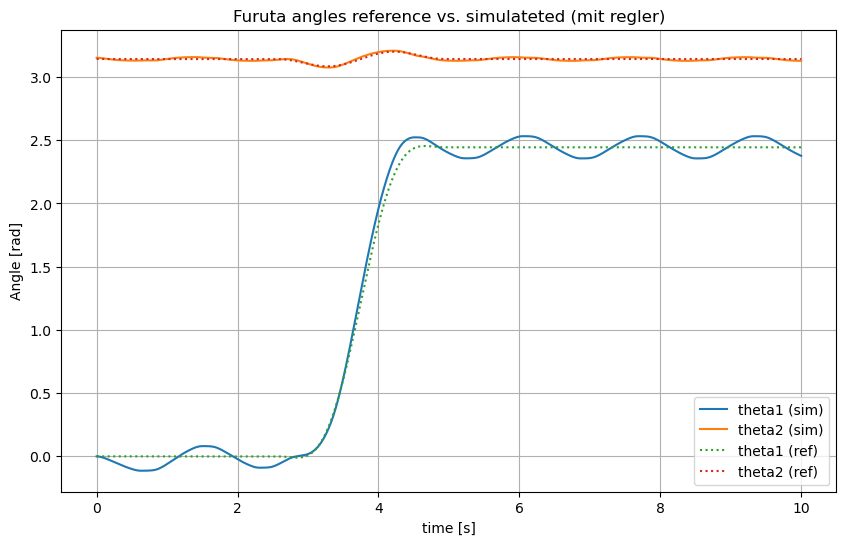

In [5]:
#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("Furuta angles reference vs. simulateted (mit regler)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()